### Make two-part linear model

##### 1. Make your own example that calls for a two-part linear model.
- Invent plausible story 
- Make fake data 
- Apply a model 

**My history**

Jesteś dziennikarzem śledczym zajmującym się problemami akustycznymi w środowisku. Lokalne stowarzyszenie mieszkańców zgłosiło ci, że pobliska farma wiatrowa może generować zbyt duży hałas, szczególnie w okresach silnych podmuchów. Nie masz oficjalnych norm dotyczących poziomu dźwięku dla tej konkretnej lokalizacji, ale dobrze wiesz, że hałas turbin rośnie liniowo wraz ze wzrostem prędkości wiatru — im szybciej obracają się łopaty, tym głośniejsza jest cała konstrukcja.

Masz dostęp do pomiarów z ostatnich 26 dni, obejmujących prędkość wiatru i odpowiadający jej poziom hałasu. Twoim zadaniem jest sprawdzić, czy zaobserwowany hałas wygląda na naturalny, czy może wskazuje na jakiś problem techniczny lub nieprawidłową eksploatację turbin.

**Fake data**

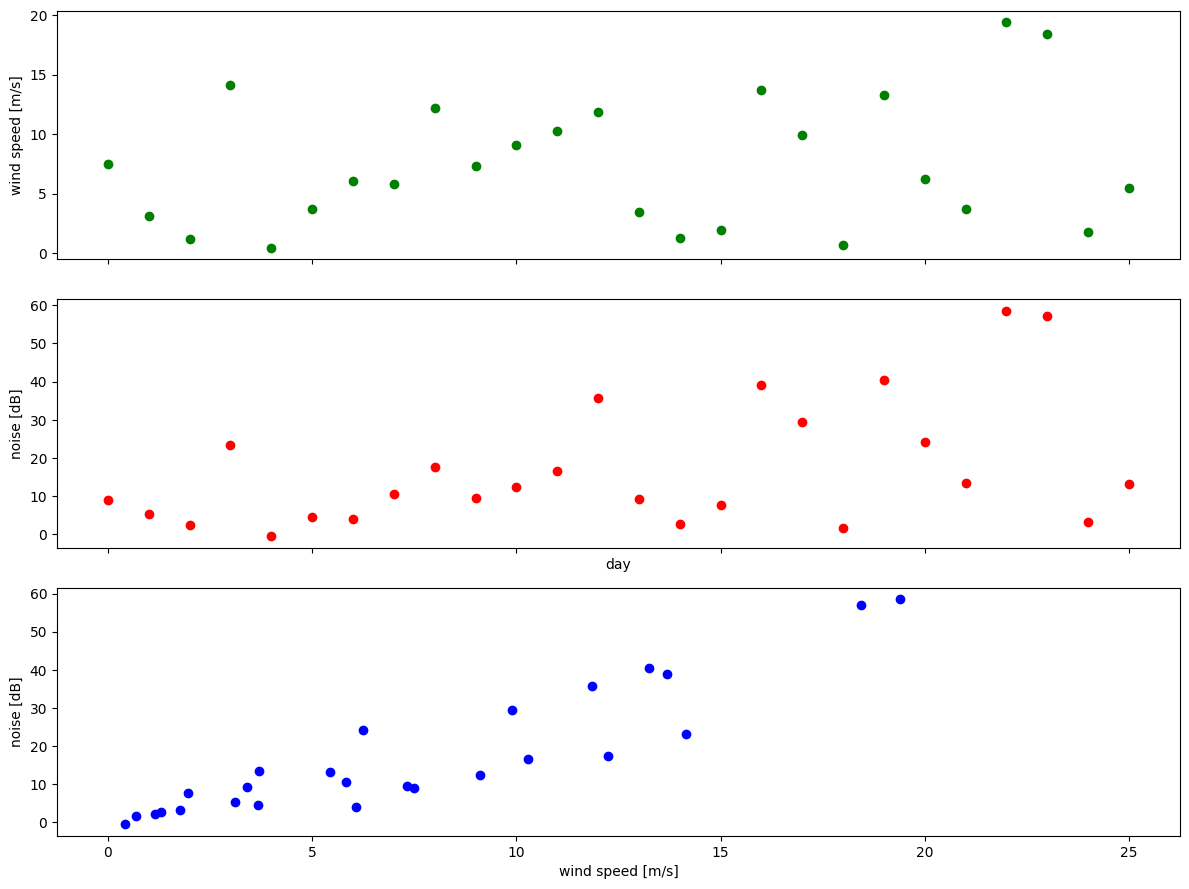

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

days = np.arange(0, 26)
failure_start = 12

def calculate_noise(wind_speed, is_failure=False, noise = 2, failure_coef=3):
    if is_failure:
        return  failure_coef * wind_speed + np.random.normal(0, noise)
    return 1.5 * wind_speed + np.random.normal(0, noise)

wind_speeds = []
noises = []

for day in days:
    wind_speed = np.random.uniform(0, 20)
    is_failure = failure_start <= day
    noise_level = calculate_noise(wind_speed, is_failure)
    wind_speeds.append(wind_speed)
    noises.append(noise_level)
    # print(f"Day {day}: Wind Speed = {wind_speed:.2f} m/s, Noise = {noise_level:.2f} dB, Failure = {is_failure}")

fig, axs = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axs[0].scatter(days, wind_speeds, color='green')
axs[0].set_ylabel("wind speed [m/s]")

axs[1].scatter(days, noises, color='red')
axs[1].set_ylabel("noise [dB]")
axs[1].set_xlabel("day")

axs[2].scatter(wind_speeds, noises, color='blue')
axs[2].set_xlabel("wind speed [m/s]")
axs[2].set_ylabel("noise [dB]")

plt.tight_layout()
plt.show()



**Model**

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [b_1, b_2, sigma_e]
>Metropolis: [tau]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 18 seconds.
c:\Users\Filip\Documents\mgr-siium\metody_probabilistycznej_analizy_danych\.venv\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


array([<Axes: title={'center': 'sigma_e'}>,
       <Axes: title={'center': 'b_1'}>, <Axes: title={'center': 'b_2'}>,
       <Axes: title={'center': 'tau'}>], dtype=object)

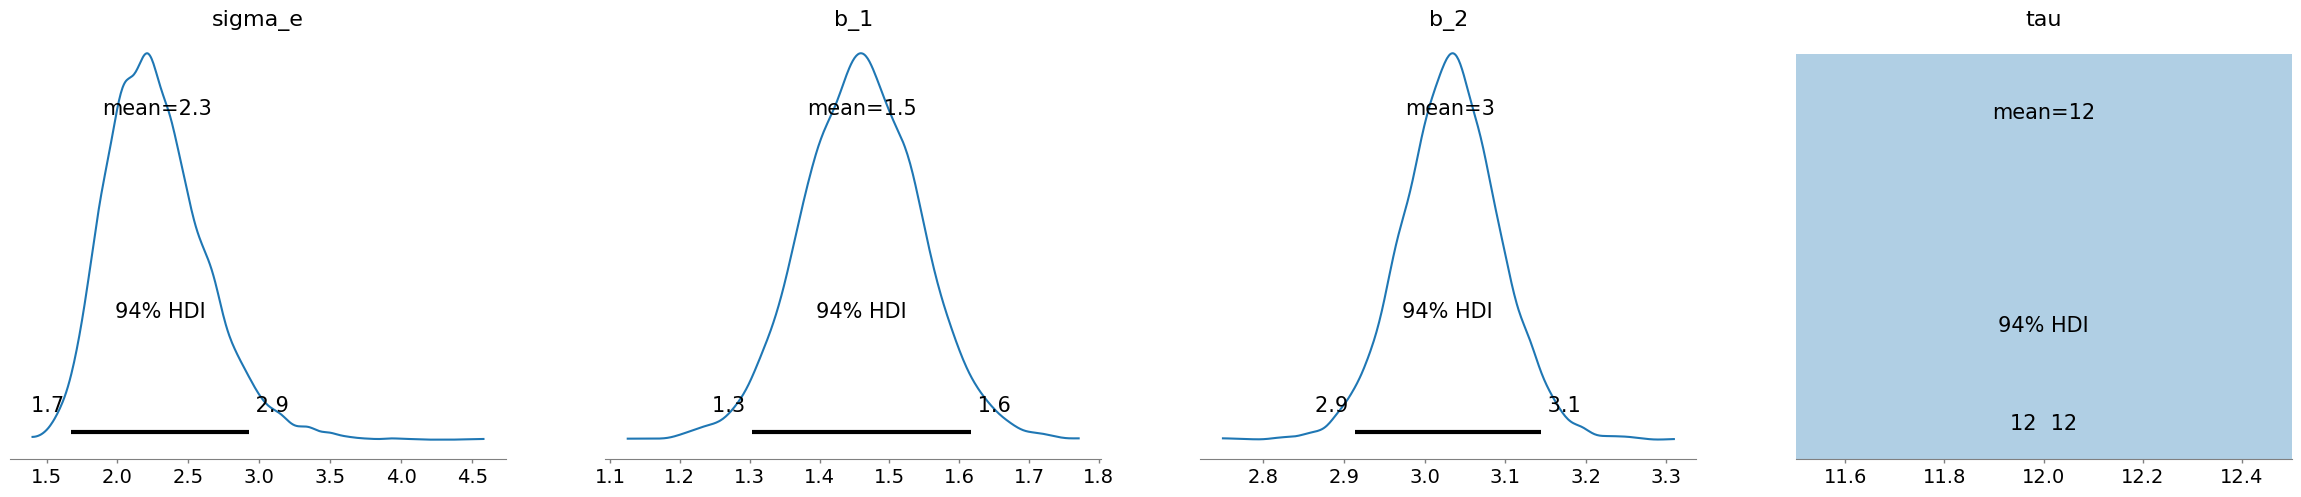

In [32]:
import pymc as pm  
import arviz as az

with pm.Model() as model:
    b_1 = pm.Uniform("b_1", lower=-20, upper=20)
    b_2 = pm.Uniform("b_2", lower=-20, upper=20)
    tau = pm.DiscreteUniform("tau", lower=0, upper=len(wind_speeds) - 1)
    idx = np.arange(len(wind_speeds)) 
    b = pm.math.switch(tau > idx, b_1, b_2)
    m_e = pm.Deterministic("m_e", b * wind_speeds)
    sigma_e = pm.Uniform("sigma_e", lower=0.1, upper=100)
    decibels = pm.Normal("decibels", mu=m_e, sigma=sigma_e, observed=noises)
    idata = pm.sample(2000, tune=2500)

az.plot_posterior(
    idata,
    var_names=["sigma_e", "b_1", "b_2", "tau"],
    hdi_prob=0.94,
)



##### 2. Check how the model behaves when in the data
- The difference between the two parts becomes less pronounced 

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [b_1, b_2, sigma_e]
>Metropolis: [tau]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 17 seconds.
c:\Users\Filip\Documents\mgr-siium\metody_probabilistycznej_analizy_danych\.venv\Lib\site-packages\arviz\stats\diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


array([<Axes: title={'center': 'sigma_e'}>,
       <Axes: title={'center': 'b_1'}>, <Axes: title={'center': 'b_2'}>,
       <Axes: title={'center': 'tau'}>], dtype=object)

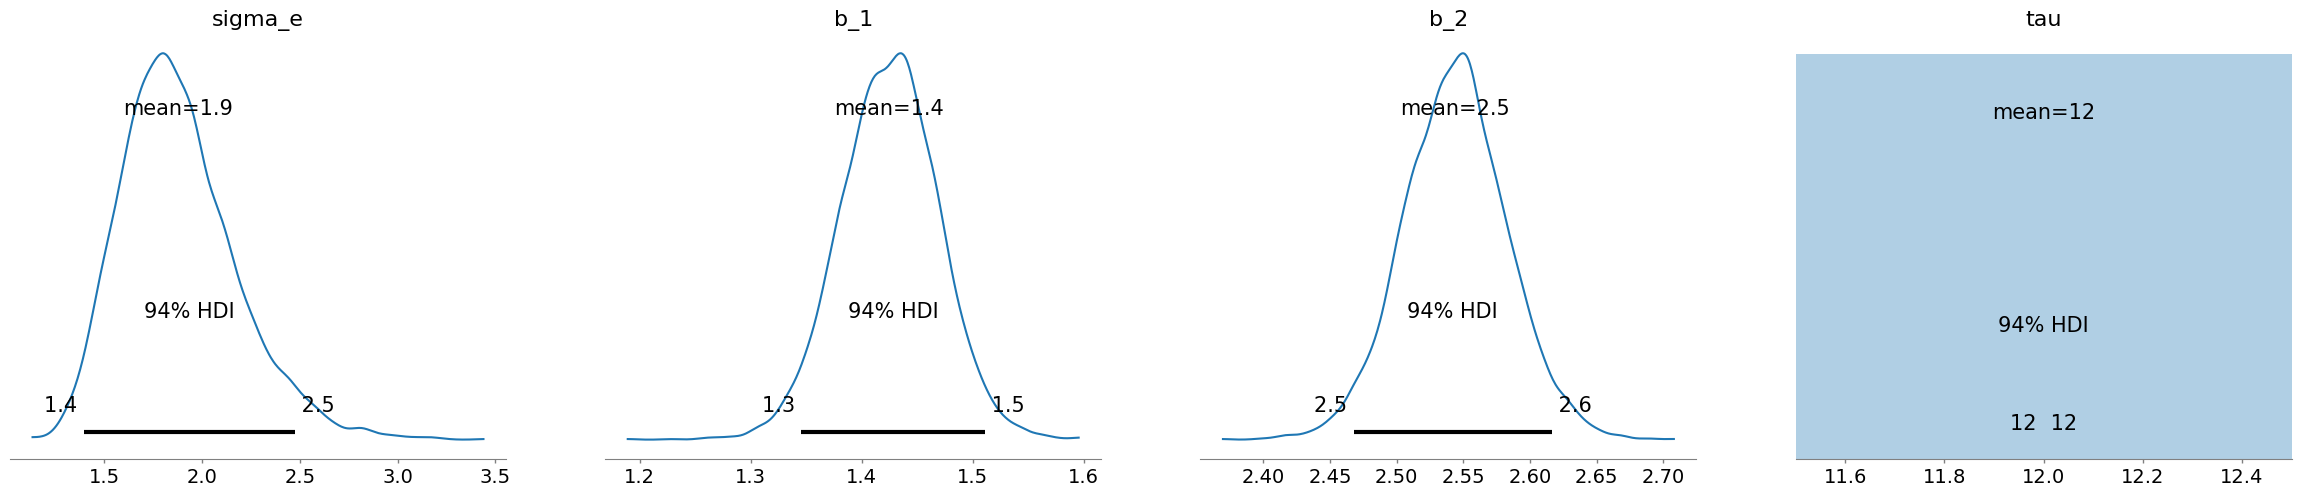

In [33]:
wind_speeds = []
noises = []

for day in days:
    wind_speed = np.random.uniform(0, 20)
    is_failure = failure_start <= day
    noise_level = calculate_noise(wind_speed, is_failure, failure_coef=2.5)
    wind_speeds.append(wind_speed)
    noises.append(noise_level)


with pm.Model() as model:
    b_1 = pm.Uniform("b_1", lower=-20, upper=20)
    b_2 = pm.Uniform("b_2", lower=-20, upper=20)
    tau = pm.DiscreteUniform("tau", lower=0, upper=len(wind_speeds) - 1)
    idx = np.arange(len(wind_speeds)) 
    b = pm.math.switch(tau > idx, b_1, b_2)
    m_e = pm.Deterministic("m_e", b*wind_speeds)
    sigma_e = pm.Uniform("sigma_e", lower=0.1, upper=100)
    decibels = pm.Normal("decibels", mu=m_e, sigma=sigma_e, observed=noises)
    idata = pm.sample(2000, tune=2500)

az.plot_posterior(
    idata,
    var_names=["sigma_e", "b_1", "b_2", "tau"],
    hdi_prob=0.94,
)

- Noise increases 

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [b_1, b_2, sigma_e]
>Metropolis: [tau]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 17 seconds.


array([<Axes: title={'center': 'sigma_e'}>,
       <Axes: title={'center': 'b_1'}>, <Axes: title={'center': 'b_2'}>,
       <Axes: title={'center': 'tau'}>], dtype=object)

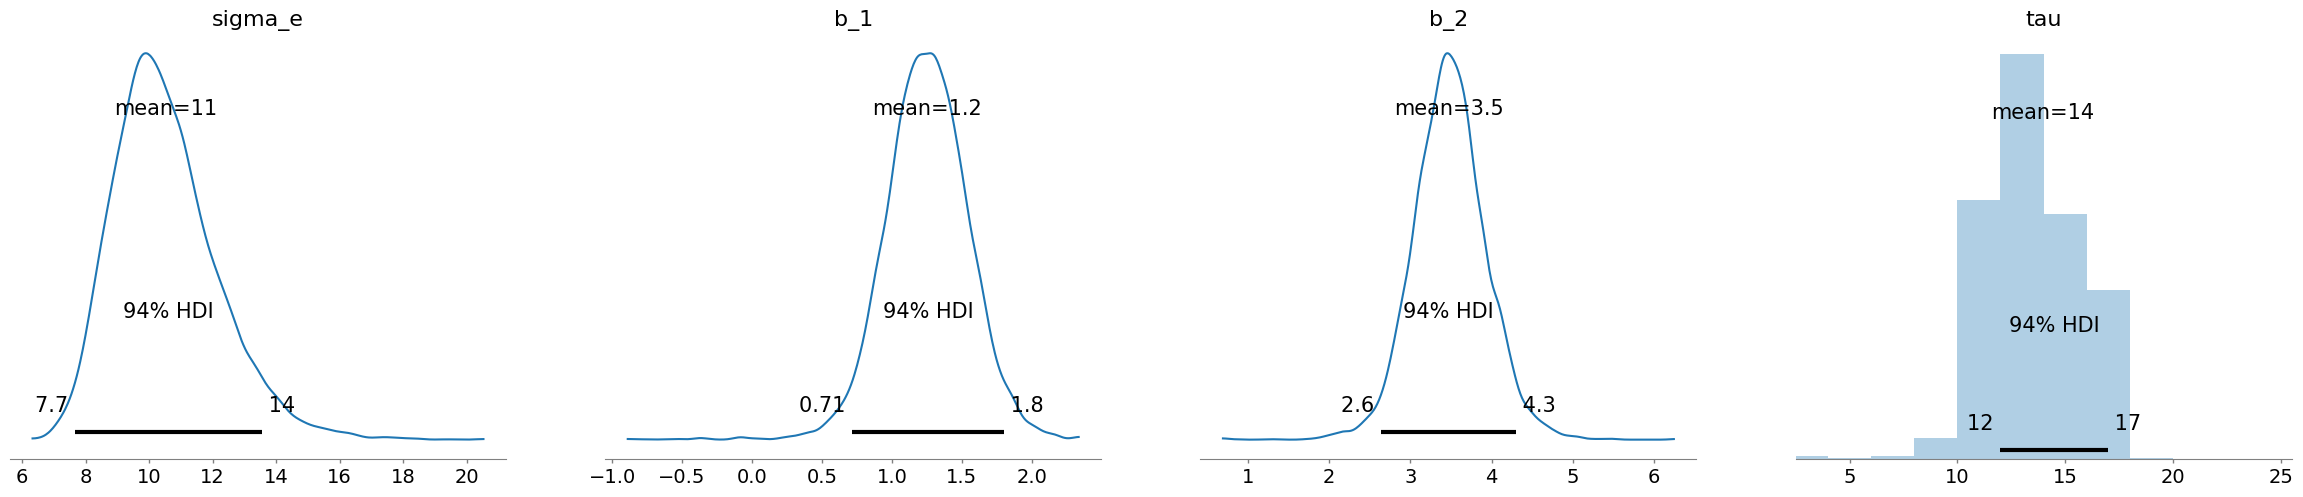

In [34]:
wind_speeds = []
noises = []

for day in days:
    wind_speed = np.random.uniform(0, 20)
    is_failure = failure_start <= day
    noise_level = calculate_noise(wind_speed, is_failure, noise=10)
    wind_speeds.append(wind_speed)
    noises.append(noise_level)


with pm.Model() as model:
    b_1 = pm.Uniform("b_1", lower=-20, upper=20)
    b_2 = pm.Uniform("b_2", lower=-20, upper=20)
    tau = pm.DiscreteUniform("tau", lower=0, upper=len(wind_speeds) - 1)
    idx = np.arange(len(wind_speeds)) 
    b = pm.math.switch(tau > idx, b_1, b_2)
    m_e = pm.Deterministic("m_e", b*wind_speeds)
    sigma_e = pm.Uniform("sigma_e", lower=0.1, upper=100)
    decibels = pm.Normal("decibels", mu=m_e, sigma=sigma_e, observed=noises)
    idata = pm.sample(2000, tune=2500)

az.plot_posterior(
    idata,
    var_names=["sigma_e", "b_1", "b_2", "tau"],
    hdi_prob=0.94,
)


- The switch occurs more gradually

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [b_1, b_2, sigma_e]
>Metropolis: [tau]


Output()

Sampling 4 chains for 2_500 tune and 2_000 draw iterations (10_000 + 8_000 draws total) took 17 seconds.


array([<Axes: title={'center': 'sigma_e'}>,
       <Axes: title={'center': 'b_1'}>, <Axes: title={'center': 'b_2'}>,
       <Axes: title={'center': 'tau'}>], dtype=object)

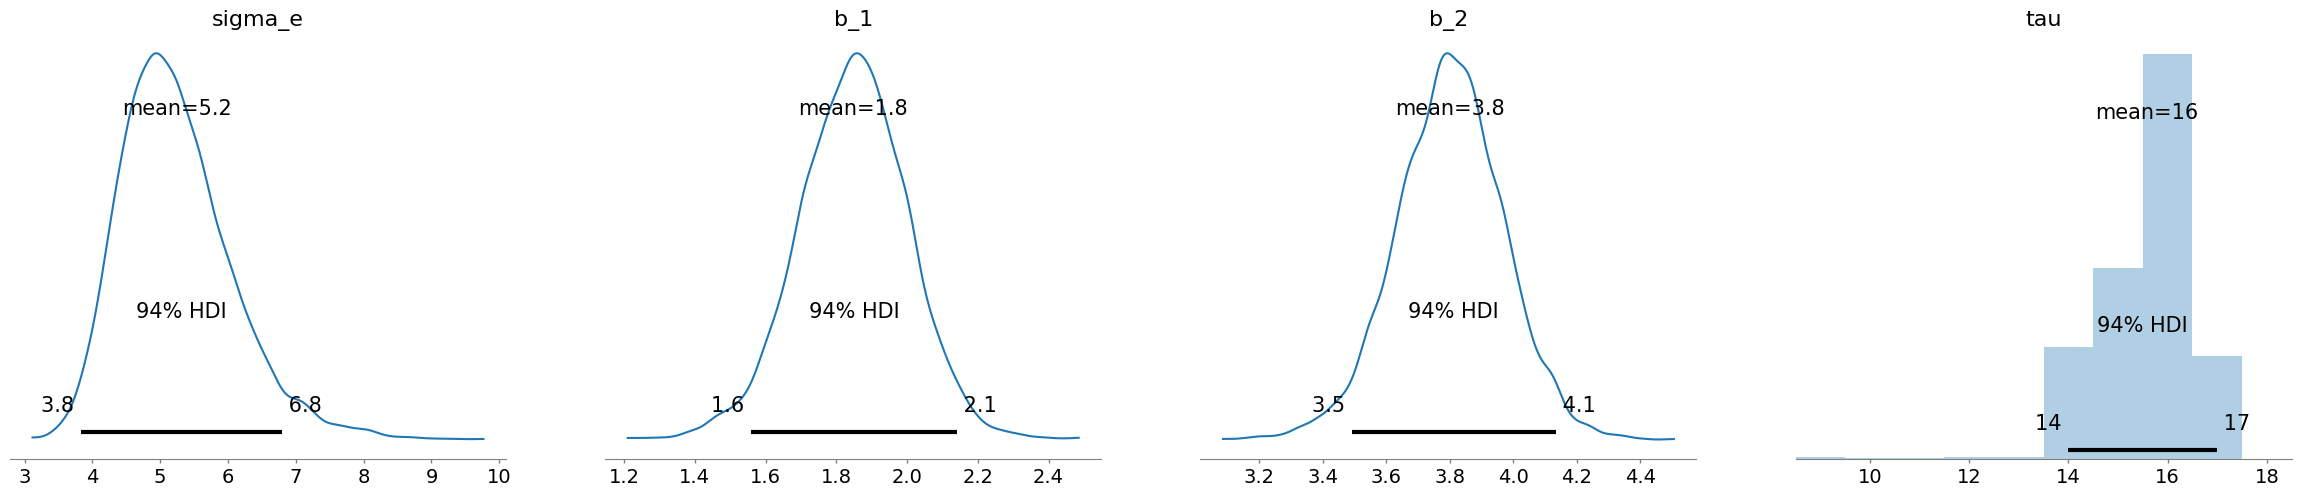

In [35]:
wind_speeds = []
noises = []

for day in days:
    wind_speed = np.random.uniform(0, 20)
    is_failure = failure_start <= day
    noise_level = calculate_noise(wind_speed, is_failure, failure_coef=2 + (day + 1 - failure_start) * 0.2)
    wind_speeds.append(wind_speed)
    noises.append(noise_level)


with pm.Model() as model:
    b_1 = pm.Uniform("b_1", lower=-20, upper=20)
    b_2 = pm.Uniform("b_2", lower=-20, upper=20)
    tau = pm.DiscreteUniform("tau", lower=0, upper=len(wind_speeds) - 1)
    idx = np.arange(len(wind_speeds)) 
    b = pm.math.switch(tau > idx, b_1, b_2)
    m_e = pm.Deterministic("m_e", b*wind_speeds)
    sigma_e = pm.Uniform("sigma_e", lower=0.1, upper=100)
    decibels = pm.Normal("decibels", mu=m_e, sigma=sigma_e, observed=noises)
    idata = pm.sample(2000, tune=2500)

az.plot_posterior(
    idata,
    var_names=["sigma_e", "b_1", "b_2", "tau"],
    hdi_prob=0.94,
)

**Wnioski**

- Dwuczęściowy model liniowy dobrze sprawdza się w przypadku danych, w których zachodzi nagła zmiana w trendzie zależności pomiędzy zmiennymi - w naszym przykładzie było to nagłe zwiększenie hałasu po wystąpieniu awarii turbin wiatrowych. Model pozwalał na wyznaczenie punktu przełamania (tau), co odpowiadało dniu, w którym turbiny zaczęły działać nieprawidłowo.
- Wpływ szumu (sigma_e) na model: większa losowość w danych powodowała bardziej rozmyty punkt przełamania i większą niepewność estymacji nachyleń. W praktyce oznacza to, że przy pomiarach o dużych wahaniach naturalnych lub zakłóceniach trudniej jednoznacznie określić moment awarii.
- Wielkość nachylenia segmentów (b_1 i b_2) odzwierciedlała intensywność wpływu prędkości wiatru na poziom hałasu przed i po awarii. W przypadku, gdy różnica między segmentami była wyraźna, model łatwo wychwytywał zmianę trendu. Gdy różnica była mniejsza, wykres posterior był bardziej rozmyty, a punkt tau mniej dokładny.